In [ ]:
!gcloud auth application-default login

from google.cloud import storage
client = storage.Client(project="lr_schedules")

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=svqZ4nLQtj8i47wAEslQYBLISshbSW&prompt=consent&token_usage=remote&access_type=offline&code_challenge=QZ3ruKRXPoksmDwKsq_C_iN0YXR6wB8WDA5ilN7gll0&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0ASc3gC0YJlUPxI-3tnMRAtnWFeL6uFzmRqkJo6Pxg-Sn2pSdi0qcxhlFq78O5022i0dLFQ

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [ ]:
import sys
from google.cloud import storage
import numpy as np
import io
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:


def download_and_load_npz(bucket_name, file_path):
    """
    Download an NPZ file from Google Cloud Storage and load it as a numpy file.

    Args:
        bucket_name: Name of the GCS bucket (e.g., 'gresearch')
        file_path: Path pattern in the bucket (e.g., 'cifar5m/part{}.npz')
        i: Index to format into the file path

    Returns:
        Loaded numpy archive object
    """
    # Initialize GCS client
    client = storage.Client(project="lr_schedules")
    bucket = client.bucket(bucket_name)

    # Format the file path with the index
    file_name = file_path
    blob = bucket.blob(file_name)

    # Download file to memory
    file_data = blob.download_as_bytes()

    # Load as numpy array
    data = np.load(io.BytesIO(file_data))

    return data

"""
# Example usage
if __name__ == "__main__":
    bucket_name = "gresearch"
    file_path = "cifar5m/part0.npz"

    # Download and load part 0
    data = download_and_load_npz(bucket_name, file_path)
"""


'\n# Example usage\nif __name__ == "__main__":\n    bucket_name = "gresearch"\n    file_path = "cifar5m/part0.npz"\n\n    # Download and load part 0\n    data = download_and_load_npz(bucket_name, file_path)\n'

In [ ]:
print(data.keys())

print(data['X'].shape)
print(data['Y'].shape)

KeysView(NpzFile 'object' with keys: X, Y)
(1000448, 32, 32, 3)
(1000448,)


In [ ]:


class GrayscaleFlattenedDataset(Dataset):
    def __init__(self, data):
        """
        Args:
            data (np.ndarray): Numpy array of shape (N, H, W, C) where C is 3 for RGB.
        """
        self.data = data

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        # Get the RGB image
        rgb_image = self.data[idx]

        # Grayscale transformation
        # Using the formula: Gray = 0.2989*R + 0.5870*G + 0.1140*B (common standard)
        # Note: The user's previous code used different coefficients (0.3, 0.58, 0.114).
        # Using the standard here for better practice, but can be adjusted.
        grayscale_image = 0.2989 * rgb_image[:,:,0] + 0.5870 * rgb_image[:,:,1] + 0.1140 * rgb_image[:,:,2]

        # Flatten the grayscale image
        flattened_image = grayscale_image.flatten()

        # Convert to torch tensor
        flattened_image = torch.tensor(flattened_image, dtype=torch.long)

        # Assuming labels are available in a separate array 'data_Y' from previous steps
        # If not, this part needs adjustment based on how labels are stored.
        # For this example, we'll assume a placeholder label or remove it if not needed.
        # If you have labels, you'll need to pass them to the Dataset or modify this.
        # For now, let's assume no labels are needed for this specific DataLoader task.
        # If you need labels, please provide the variable name where they are stored.

        return flattened_image

# Example usage (assuming 'data' from previous steps is available and contains 'X')
if 'data' in locals() and 'X' in data:
    dataset = GrayscaleFlattenedDataset(data['X'])
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    # Example of iterating through the dataloader
    # for batch in dataloader:
    #     print(batch.shape)
    #     break # Process one batch for demonstration

else:
    print("The variable 'data' containing 'X' (image data) was not found.")
    print("Please ensure the data is loaded before creating the DataLoader.")

In [ ]:
for batch in dataloader:
    print(batch.shape)
    print(batch[:4,:4])
    print(torch.amax(batch))
    print(torch.amin(batch))
    break

torch.Size([64, 1024])
tensor([[251, 248, 250, 250],
        [166, 168, 169, 168],
        [253, 251, 251, 251],
        [ 45,  45,  60,  63]])
tensor(254)
tensor(0)


In [ ]:
CUDA_LAUNCH_BLOCKING = 1

In [ ]:
# dense layer with muP scaling (for Adam)
class mup_Dense(nn.Module):

  def __init__(self, fan_in, fan_out, base_width, device, std = 0.2):
        super().__init__()
        self.fan_in = fan_in
        self.fan_out = fan_out
        self.base_width = base_width
        self.linear = nn.Linear(fan_in, fan_out, bias = False, device=device)
        self.std = std

  def forward(self, x):
        return self.base_width / self.fan_in * self.linear(x)

  def reset_parameters(self):
        nn.init.normal_( self.linear.linear, std = self.std * math.sqrt( self.fan_in / self.base_width ))


class AttentionBlock(nn.Module):
    def __init__(self, embed_size, heads, base_embed, base_heads, device):
        super(AttentionBlock, self).__init__()
        self.embed_size = embed_size
        self.base_embed = base_embed
        self.heads = heads
        self.head_dim = embed_size // heads
        self.base_head_dim = base_embed // base_heads
        assert (
            self.head_dim * heads == embed_size
        ), "Embedding size needs to be divisible by heads"

        self.qkv = mup_Dense(self.embed_size, 3 * self.embed_size, self.base_embed, device = device)
        self.fc_out = mup_Dense(self.heads * self.head_dim, self.embed_size, self.base_embed, device = device)

    def forward(self, x, mask):

        # x is B x T x d
        # Split the embedding into self.heads different pieces
        qkv = self.qkv( x )
        q, k, v = qkv.split( [self.embed_size for i in range(3)], dim = -1)

        B, T, _ = x.shape
        q = q.view( (B, T, self.heads, self.head_dim) ) # B x T x H x d
        k = k.view( (B, T, self.heads, self.head_dim) ) # B x T x H x d
        v = v.view( (B, T, self.heads, self.head_dim) ) # B x T x H x d

        # Einsum does matrix multiplication for query * key * value
        # query shape: (N, query_len, heads, head_dim), key shape: (N, key_len, heads, head_dim)
        # energy shape: (N, heads, query_len, key_len)
        energy = torch.einsum("nqhd,nkhd->nhqk", [q, k]) / self.head_dim * math.sqrt(self.base_head_dim)

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        att = torch.softmax(energy, dim=3)

        out = torch.einsum("nhql,nlhd->nqhd", [att, v]).reshape(
            B, T, self.heads * self.head_dim
        )

        out = self.fc_out(out)
        return out

    def reset_parameters(self):
        self.qkv.reset_parameters()
        self.fc_out.reset_parameters()




class TransformerBlock(nn.Module):
    def __init__(self, embed_size, base_embed, heads, base_heads, forward_expansion, res_mult, device):
        super(TransformerBlock, self).__init__()
        self.attention = AttentionBlock(embed_size, heads, base_embed, base_heads, device)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.res_mult = res_mult

        self.feed_forward = nn.Sequential(
            mup_Dense(embed_size, forward_expansion * embed_size, base_embed, device),
            nn.ReLU(),
            mup_Dense(forward_expansion * embed_size, embed_size, forward_expansion * base_embed, device),
        )

    def forward(self, x, mask):
        att_out = self.attention( self.norm1(x) , mask) # pre-LN
        x = x + self.res_mult * att_out
        mlp_out = self.feed_forward( self.norm2(x) )
        out = x + self.res_mult * mlp_out
        return out

    def reset_parameters(self):
        self.attention.reset_parameters()
        self.feed_forward[0].reset_parameters()
        self.feed_forward[2].reset_parameters()

# decoder only model
class GPT_Model(nn.Module):
    def __init__(self, vocab, embed, base_embed, depth, base_depth, heads, base_heads, forward_expansion, device, max_length, std = 0.2):
        super(GPT_Model, self).__init__()
        self.device = device
        self.word_embedding = nn.Embedding(vocab, embed, device = device)
        self.position_embedding = nn.Embedding(max_length, embed, device = device)
        self.res_mult = base_depth / depth
        self.blocks = nn.ModuleList([TransformerBlock(embed, base_embed, heads, base_heads, forward_expansion, self.res_mult, device) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed)
        self.fc_out = mup_Dense(embed, vocab, base_embed, device, std = 0.5*std)
        self.std = std

    def make_mask(self, x):
        B, T = x.shape
        trg_mask = torch.tril(torch.ones((T, T))).expand(
            B, 1, T, T
        )
        return trg_mask.to(self.device)


    def forward(self, x):
        B, T = x.shape
        mask = self.make_mask(x)

        positions = torch.arange(0, T).expand(B, T).to(self.device)
        x = self.word_embedding(x) + self.position_embedding(positions)
        for block in self.blocks:
          x = block(x, mask)
        x = self.norm(x)
        out = self.fc_out(x)
        return out

    def reset_parameters(self):
        nn.init.normal_( self.word_embedding.weight, std = self.std)
        nn.init.normal_( self.position_embedding.weight, std = self.std)
        for block in self.blocks:
            block.reset_parameters()
        self.fc_out.reset_parameters()

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    #x = torch.tensor([[1, 5, 6, 4, 3, 9, 5, 2, 0], [1, 8, 7, 3, 4, 5, 6, 7, 2]]).to(
    #   device
    #)

    vocab = 255
    embed = 384
    base_embed = 384
    depth = 2
    base_depth = 2
    heads = 6
    base_heads = 6
    forward_expansion = 2
    max_length = 1024


    model = GPT_Model(vocab, embed, base_embed, depth, base_depth, heads, base_heads, forward_expansion, device, max_length).to(
        device)


Using device: cuda


In [ ]:
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss = nn.CrossEntropyLoss()

losses = []

steps = 100
for i, batch in enumerate(dataloader):
  x = batch.to(device)
  out = model( x )
  #print(out.shape)
  #print(x.shape)
  loss_t = loss( out[:,:-1].transpose(1,2), x[:,1:] )
  loss_t.backward()
  sys.stdout.write(f"\r{loss_t.item()}")
  optimizer.step()
  optimizer.zero_grad()
  losses += [loss_t.item()]
  if i > steps:
    break

4.108930587768555

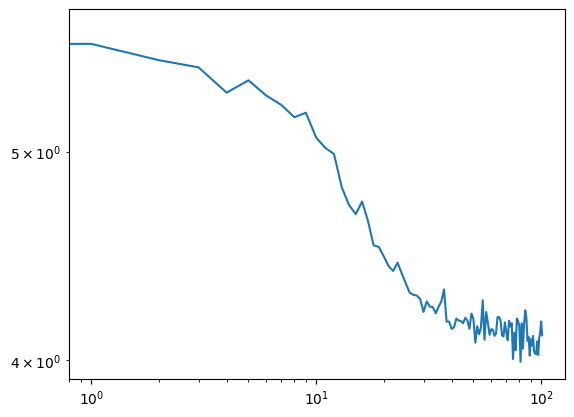

In [ ]:
plt.loglog(losses)
plt.show()

In [ ]:
print(batch.shape)

torch.Size([32, 1024])


In [ ]:
all_heads = [1,2,4,8]

vocab = 255
base_embed = 64
depth = 2
base_depth = 2
base_heads = 2
forward_expansion = 1
max_length = 1024
batch_size = 32

steps = 10000

lr = 0.01

all_losses = []
for i, heads in enumerate(all_heads):


  #dataset = GrayscaleFlattenedDataset(data['X'])
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers = 4)


  embed = 64*heads
  model = GPT_Model(vocab, embed, base_embed, depth, base_depth, heads, base_heads, forward_expansion, device, max_length).to(
        device)

  optimizer = optim.Adam(model.parameters(), lr= lr)
  loss = nn.CrossEntropyLoss()

  losses = []
  print(" ")
  print(f"heads = {heads}")

  for i, batch in enumerate(dataloader):
    x = batch.to(device)
    print(x.shape)
    out = model( x )
    #print(out.shape)
    #print(x.shape)
    loss_t = loss( out[:,:-1].transpose(1,2), x[:,1:] )
    loss_t.backward()
    sys.stdout.write(f"\r step {i}, loss {loss_t.item()}")
    optimizer.step()
    optimizer.zero_grad()
    losses += [loss_t.item()]
    if i > steps:
      break

  all_losses += [losses]

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


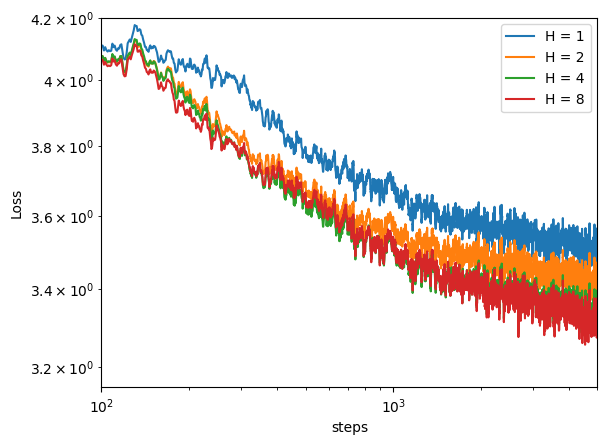

In [ ]:
for i, loss in enumerate(all_losses):

  conv_loss = np.convolve(loss, np.ones(10)/10, mode='valid')
  plt.loglog(conv_loss, label = f"H = {all_heads[i]}")

plt.xlim([100,5000])
plt.ylim([3.15,4.2])
plt.xlabel('steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#losses_saved = np.array(all_losses)
#save_path = f'/content/drive/MyDrive/LR_Schedule/losses_mup_vary_heads_fixed_LR_batch_{batch_size}_steps_{steps}.npy' # Example: saving to a folder named 'Colab_Output'
#np.save(save_path, losses_saved)

Mounted at /content/drive


In [ ]:
loaded_arr = np.load('/content/drive/MyDrive/LR_Schedule/losses_mup_vary_heads_fixed_LR.npy')

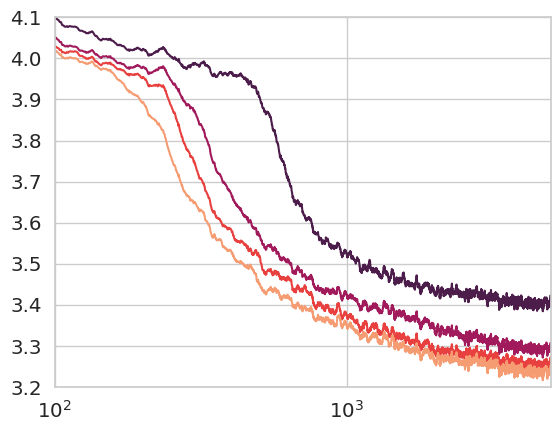

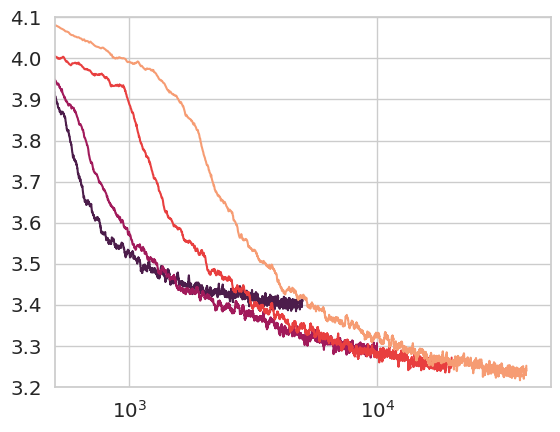

In [ ]:
import seaborn as sns


sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(loaded_arr))


for i, loss in enumerate(loaded_arr):
  conv_loss = np.convolve(loss, np.ones(25)/25, mode='valid')
  plt.semilogx(conv_loss)
plt.xlim([1e2,5000])
plt.ylim([3.2,4.1])
plt.show()


for i, loss in enumerate(loaded_arr):
  conv_loss = np.convolve(loss, np.ones(25)/25, mode='valid')
  plt.semilogx(all_heads[i] * np.linspace(1,len(conv_loss),len(conv_loss)) , conv_loss)
plt.xlim([500,50000])
plt.ylim([3.2,4.1])
plt.show()




In [ ]:
import scipy as sp

def powerlaw_fn(x, a, b, c, d, e):

  times = x[0]
  heads = x[1]

  return a * times**b + c * heads**d + e

loss = loaded_arr[0]
t0 = 700
times = np.linspace(t0,len(loss),len(loss)-t0)
x_data = np.zeros((2 , len(times) * len(all_heads)))
for i, head in enumerate(all_heads):
  x_data[0,i*len(times):(i+1)*len(times)] = times
  x_data[1,i*len(times):(i+1)*len(times)] = head


print(loaded_arr[:,t0:].flatten())

result,_ = sp.optimize.curve_fit(powerlaw_fn, x_data, loaded_arr[:,t0:].flatten(), p0=[ 1.0, -0.5, 1.0, -0.1 , 3.0 ])

[3.6705699  3.67173839 3.65262008 ... 3.33741665 3.32662058 3.19846511]


[145.66279084  -0.99146413   0.18105563  -1.21709368   3.18548035]


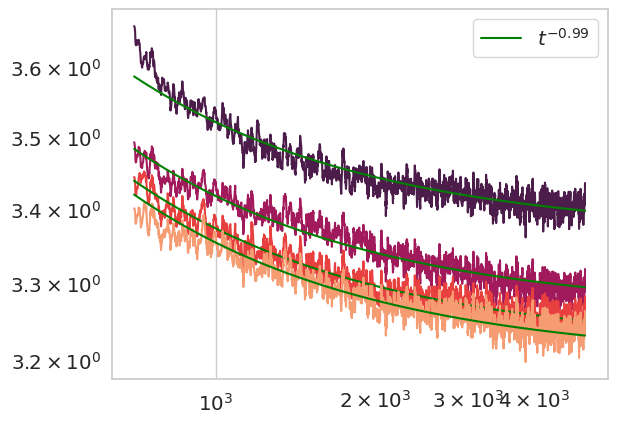

In [ ]:
print(result)

for i, head in enumerate(all_heads):
  predicted_curve = powerlaw_fn( np.array([times, head*np.ones(len(times))]), *result)

  conv_loss = np.convolve(loaded_arr[i,t0:], np.ones(10)/10, mode='valid')
  plt.loglog(np.linspace(t0,len(loss),len(conv_loss)), conv_loss)
  plt.loglog(np.linspace(t0,len(loss),len(loss)-t0),predicted_curve, color = 'green')
plt.loglog([],[], color = 'green', label ='$t^{%0.2f}$' % result[1])
plt.legend()
plt.show()

## Scaling Law for Fixed LR and Varying $T$

In [ ]:
vocab = 255
base_embed = 32
depth = 4
heads = 4
base_depth = 2
base_heads = 2
forward_expansion = 1

max_length = 1024
batch_size = 32

all_steps = [10000]

lr = 0.02

all_losses = []
for i, steps in enumerate(all_steps):


  #dataset = GrayscaleFlattenedDataset(data['X'])
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers = 4)


  embed = 32*heads
  model = GPT_Model(vocab, embed, base_embed, depth, base_depth, heads, base_heads, forward_expansion, device, max_length).to(
        device)


  optimizer = optim.Adam(model.parameters(), lr= lr)
  loss = nn.CrossEntropyLoss()

  losses = []
  print(" ")
  print(f"heads = {heads}")

  for i, batch in enumerate(dataloader):
    x = batch.to(device)
    out = model( x )
    #print(out.shape)
    #print(x.shape)
    loss_t = loss( out[:,:-1].transpose(1,2), x[:,1:] )
    loss_t.backward()
    sys.stdout.write(f"\r step {i}, loss {loss_t.item()}")
    optimizer.step()
    optimizer.zero_grad()
    losses += [loss_t.item()]
    if i > steps:
      break

  all_losses += [losses]

 
heads = 4
 step 10001, loss 3.280712366104126

In [ ]:
for i,T in enumerate(all_steps):
  save_path = f'/content/drive/MyDrive/LR_Schedule/losses_mup_fixed_heads_no_anneal_T_{T}.npy' # Example: saving to a folder named 'Colab_Output'
  np.save(save_path, all_losses[i])

In [ ]:
losses_vary_T_loaded = []
for i, T in enumerate(all_steps):
  losses_vary_T_loaded += [np.load(f'/content/drive/MyDrive/LR_Schedule/losses_mup_fixed_heads_no_anneal_T_{T}.npy')]

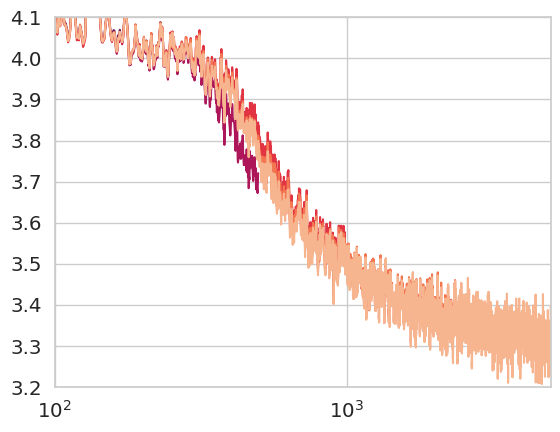

In [ ]:
import seaborn as sns


sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(losses_vary_T_loaded))


for i, loss in enumerate(losses_vary_T_loaded):
  conv_loss = np.convolve(loss, np.ones(5)/5, mode='valid')
  plt.semilogx(conv_loss)
plt.xlim([1e2,5000])
plt.ylim([3.2,4.1])
plt.show()



<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-641663629.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(r'$\mathcal{L}-\mathcal{L}_0$',fontsize = 20)


[67.04998635 -0.80068507  3.22929883]


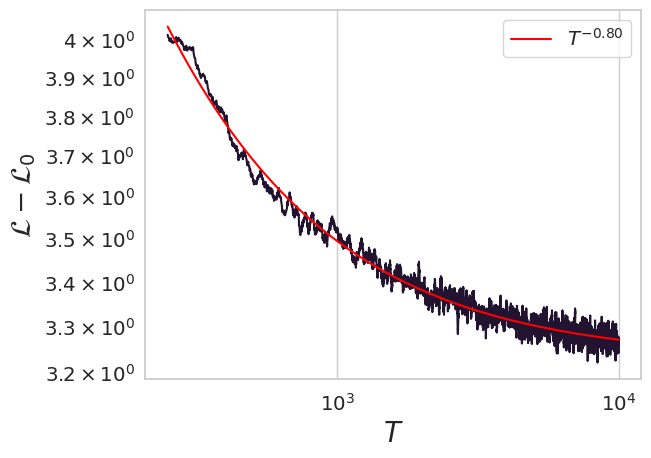

In [ ]:
import scipy as sp
# fit T scaling law , should represent bias...
"""
Tmaxes = np.array(all_steps)

final_losses = np.array([np.array(loss[-50:-1]).mean() for loss in losses_vary_T_loaded])

print(final_losses.shape)
print(Tmaxes)

result,_ = sp.optimize.curve_fit(one_var_power, np.array(Tmaxes), final_losses, p0=[ 100.0, -1.0 , 3.0 ])

print(result)

plt.loglog(Tmaxes, [ np.array(loss[-50:-1]).mean()-result[-1] for loss in all_losses], '-o')
plt.loglog(Tmaxes, one_var_power(Tmaxes, *result) - result[-1], color = 'green', label = r'$T^{%0.2f}$' % result[1])
plt.xlabel(r'$T$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}-\mathcal{L}_0$',fontsize = 20)
plt.legend()
plt.show()
"""

Tmaxes = np.array(all_steps)

def one_var_power(x, a, b, c):
  return a * x**b + c


t_cut = 250
last_curve = losses_vary_T_loaded[-1]
#last_curve = last_curve[t_cut:]
last_curve = np.convolve(last_curve, np.ones(20)/20, mode='valid')[t_cut:]

ts_last = np.linspace(t_cut, Tmaxes[-1], len(last_curve))
result,_ = sp.optimize.curve_fit(one_var_power, ts_last, last_curve, p0=[ 100.0, -1.0 , 3.0 ])

print(result)
import seaborn as sns


sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=10)

plt.loglog(ts_last, last_curve)
plt.loglog(ts_last, one_var_power(ts_last, *result), color = 'red', label = r'$T^{%0.2f}$' % result[1])
#plt.xlim([100,5000])
#plt.ylim([3,4.5])
plt.xlabel(r'$T$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}-\mathcal{L}_0$',fontsize = 20)
plt.legend()
plt.savefig(f'pixel_pred_scaling_single_run_T_{T}.pdf', bbox_inches = 'tight')
plt.show()


### Run Annealing Experiment

In [ ]:

Tmaxes = [ 50000 ]

vocab = 255
base_embed = 32
depth = 4
heads = 4
base_depth = 2
base_heads = 2
forward_expansion = 1

max_length = 1024
batch_size = 16


all_losses = []

base_lr = 0.1

zeta = 0.4

T_base = 500

for i, Tmax in enumerate(Tmaxes):


  #dataset = GrayscaleFlattenedDataset(data['X'])
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers = 8)


  embed = 32 * heads
  model = GPT_Model(vocab, embed, base_embed, depth, base_depth, heads, base_heads, forward_expansion, device, max_length).to(
        device)


  lr = base_lr * ( T_base / Tmax )**zeta
  optimizer = optim.Adam(model.parameters(), lr=lr)
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Tmax)

  loss = nn.CrossEntropyLoss()

  losses = []
  print(" ")
  print(f"heads = {heads}")

  for i, batch in enumerate(dataloader):
    x = batch.to(device)
    out = model( x )
    #print(out.shape)
    #print(x.shape)
    loss_t = loss( out[:,:-1].transpose(1,2), x[:,1:] )
    loss_t.backward()
    sys.stdout.write(f"\r step {i}, loss {loss_t.item()}")
    optimizer.step()
    optimizer.zero_grad()
    scheduler.step()
    losses += [loss_t.item()]
    if i > Tmax:
      break

  all_losses += [losses]

 
heads = 4
 step 50001, loss 2.9915995597839355

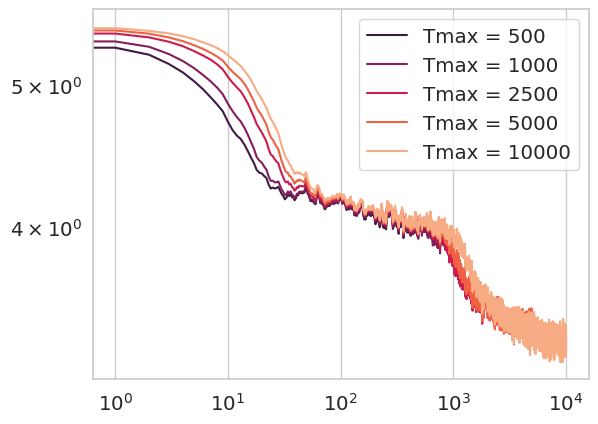

In [ ]:
sns.set_palette("rocket", n_colors=len(Tmaxes))
for i, loss in enumerate(all_losses):
  conv_loss = np.convolve(loss, np.ones(10)/10, mode='valid')
  plt.loglog(conv_loss, label = f"Tmax = {Tmaxes[i]}")
plt.legend()
plt.show()

In [ ]:


final_losses = np.array([np.array(loss[-200:-1]).mean() for loss in all_losses])

def one_var_power(x, a, b, c):
  return a * x**b + c

print(final_losses.shape)
print(Tmaxes)

result,_ = sp.optimize.curve_fit(one_var_power, np.array(Tmaxes), final_losses, p0=[ 100.0, -1.0 , 3.0 ])

print(result)

plt.loglog(Tmaxes, [ np.array(loss[-200:-1]).mean()-result[-1] for loss in all_losses], '-o')
plt.loglog(Tmaxes, one_var_power(Tmaxes, *result) - result[-1], color = 'green', label = r'$T^{%0.2f}$' % result[1])
plt.xlabel(r'$T$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}-\mathcal{L}_0$',fontsize = 20)
plt.legend()
plt.show()

In [ ]:

for i,T in enumerate(Tmaxes):
  save_path = f'/content/drive/MyDrive/LR_Schedule/losses_mup_vary_heads_cos_anneal_T_{T}.npy' # Example: saving to a folder named 'Colab_Output'
  np.save(save_path, all_losses[i])

In [ ]:
Tmaxes = [ 1000, 2500, 5000, 10000, 25000 ]

losses_vary_T_loaded = []
for i, T in enumerate(Tmaxes):
  losses_vary_T_loaded += [np.load(f'/content/drive/MyDrive/LR_Schedule/losses_mup_vary_heads_cos_anneal_T_{T}.npy')]

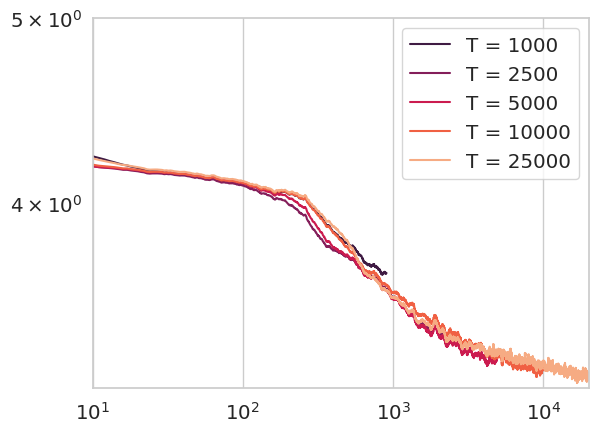

(5,)
[1000, 2500, 5000, 10000, 25000]
[730.08260779  -1.07419111   3.24024007]


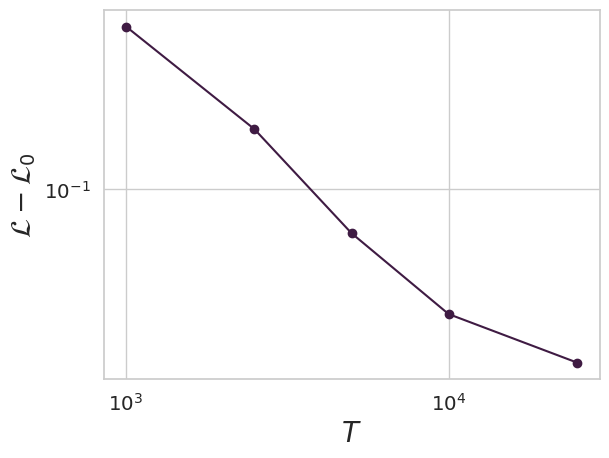

In [ ]:
import seaborn as sns
import scipy as sp

sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(losses_vary_T_loaded))

sns.set_palette("rocket", n_colors=len(Tmaxes))
for i, loss in enumerate(losses_vary_T_loaded):
  conv_loss = np.convolve(loss, np.ones(100)/100, mode='valid')
  plt.loglog(conv_loss, label = f"T = {Tmaxes[i]}")
plt.xlim([10,20000])
plt.ylim([3.2,5])
plt.legend()
plt.show()


final_losses = np.array([ np.mean(loss[-100:-1]) for loss in losses_vary_T_loaded ])


def one_var_power(x, a, b, c):
  return a * x**b + c

print(final_losses.shape)
print(Tmaxes)

result,_ = sp.optimize.curve_fit(one_var_power, np.array(Tmaxes), final_losses, p0=[ 100.0, -1.0 , 3.0 ])
print(result)

plt.loglog(Tmaxes, final_losses- result[-1], '-o')
plt.xlabel(r'$T$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}-\mathcal{L}_0$',fontsize = 20)
plt.show()

## CNN Supervised Learning

In [ ]:
import torchvision.transforms as transforms
from torch.nn import init


mean = [0.4914, 0.4822, 0.4465]
std  = [0.2470, 0.2435, 0.2616]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

class CIFAR5m(Dataset):
    def __init__(self, data, labels):
        """
        Args:
            data (np.ndarray): Numpy array of shape (N, H, W, C) where C is 3 for RGB.
        """
        self.data = data
        self.labels = labels

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):

        # Get the RGB image
        image = self.data[idx]

        # get label
        label = self.labels[idx]

        # Flatten the grayscale image
        #flattened_image = grayscale_image.flatten()

        # Convert to torch tensor
        #image = torch.tensor(rgb_image, dtype = torch.float)
        #image = transforms.Normalize(mean, std)(image)

        image = transform(image)

        return image, label



dataset = CIFAR5m(data['X'], data['Y'])
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers = 4)


for i, batch in enumerate(dataloader):
  x = batch[0]
  y = batch[1]

  print(x.shape)
  print(y[:10])
  break

torch.Size([32, 3, 32, 32])
tensor([8, 0, 1, 2, 4, 8, 5, 3, 5, 4])


In [ ]:

def _calculate_fan_in(tensor):
    dimensions = tensor.dim()
    if dimensions < 2:
        raise ValueError("Fan in and fan out can not be computed for tensor with fewer than 2 dimensions")
    num_input_fmaps = tensor.size(1)
    num_output_fmaps = tensor.size(0)
    receptive_field_size = 1
    if tensor.dim() > 2:
        for s in tensor.shape[2:]:
            receptive_field_size *= s
    fan_in = num_input_fmaps * receptive_field_size
    return fan_in



# unit variance Conv Layer
class Conv_Layer(nn.Module):

  def __init__(self, in_dim, out_dim, kernel_size = 3, stride = 1, padding = 1):

      super().__init__()
      self.conv_layer = nn.Conv2d(in_dim, out_dim, kernel_size, stride, padding, bias = False)
      self.fan_in = _calculate_fan_in(self.conv_layer.weight)

  def forward(self, x):
      return self.conv_layer(x) / math.sqrt( self.fan_in ) # 1/sqrt{N} scaling ensures O(1) entries

  def reset_parameters(self) -> None:
      init.normal_(self.conv_layer.weight)


class ResBlock(nn.Module):

  def __init__(self, width):
        super().__init__()
        self.conv1 = Conv_Layer(width, width)
        self.conv2 = Conv_Layer(width, width)
        self.ln1 = nn.LayerNorm((width, 32,32), elementwise_affine = False)

        self.beta = 1.0
        self.reset_parameters()

  def reset_parameters(self) -> None:
        self.conv1.reset_parameters()
        self.conv2.reset_parameters()


  def forward(self, x):

    residual = x
    x = self.ln1(x)
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = residual + self.beta * x
    return x



# Simple 3 Layer CNN
class CNN(nn.Module):
    def __init__(self, width, gamma0, num_classes = 10, img_dim = 32, base_width = 4):
        super().__init__()

        self.gamma0 = gamma0
        self.width = width
        self.img_dim = img_dim

        self.base_width = base_width

        self.conv1 = Conv_Layer(3, width)

        self.ln = nn.LayerNorm( [width, 32, 32], elementwise_affine = False)
        self.res1 = ResBlock(width)
        self.res2 = ResBlock(width)
        self.res3 = ResBlock(width)
        self.res4 = ResBlock(width)
        self.res5 = ResBlock(width)

        self.final_size =  self.img_dim//8
        self.final_width = int(self.final_size**2 * self.width)
        self.readout = nn.Linear( self.final_width ,  num_classes, bias = False)
        self.avgpool = nn.AvgPool2d(8)

        self.reset_all()


    # initialize weights with O(1) entries
    def reset_all(self) -> None:
        self.conv1.reset_parameters()
        self.res1.reset_parameters()
        self.res2.reset_parameters()
        self.res3.reset_parameters()
        self.res4.reset_parameters()
        self.res5.reset_parameters()

        init.normal_(self.readout.weight)


    def forward(self, x):
        x = self.conv1(x)
        x = self.ln(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        x = self.res4(x)
        x = self.res5(x)

        x = self.avgpool(x)
        x = x.view(-1, self.final_width)
        x = F.relu(x)
        x = math.sqrt( self.final_size**2 * self.base_width )/(self.gamma0) * self.readout(x) / self.final_width # MF scaling if gamma0 is constant
        return x


In [ ]:
width = 32
gamma0 = 1.0

model = CNN(width = width, gamma0 = gamma0)


In [ ]:

lr = 0.25


optimizer = optim.SGD(model.parameters(), model.gamma0**2 * model.width * lr, momentum = 0.0)
criterion = nn.CrossEntropyLoss()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
model.to(device)



cuda


CNN(
  (conv1): Conv_Layer(
    (conv_layer): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (res1): ResBlock(
    (conv1): Conv_Layer(
      (conv_layer): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (conv2): Conv_Layer(
      (conv_layer): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
  )
  (res2): ResBlock(
    (conv1): Conv_Layer(
      (conv_layer): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (conv2): Conv_Layer(
      (conv_layer): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
  )
  (res3): ResBlock(
    (conv1): Conv_Layer(
      (conv_layer): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (conv2): Conv_Layer(
      (conv_layer): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
  )
  (readout): Linear(in_feat

In [ ]:
import random


eval_every = 10
train_losses = []
train_loss = 0
correct = 0
total = 0
counter = 0
eval_every = 10
random.seed(0)
torch.manual_seed(0)
np.random.seed(0)

train_losses = []
for batch_idx, (inputs, targets) in enumerate(dataloader):

      inputs, targets = inputs.to(device), targets.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, targets)
      loss.backward()
      optimizer.step()
      train_loss += loss.item()
      _, predicted = outputs.max(1)
      total += targets.size(0)

      sys.stdout.write(f'\r loss = {loss.item()}')
      if batch_idx % eval_every == 0 and batch_idx > 0:
          train_losses += [train_loss/eval_every]
          train_loss = 0
          counter = 0
      counter += 1

      if batch_idx > 10000:
        break

 loss = 0.8257946968078613

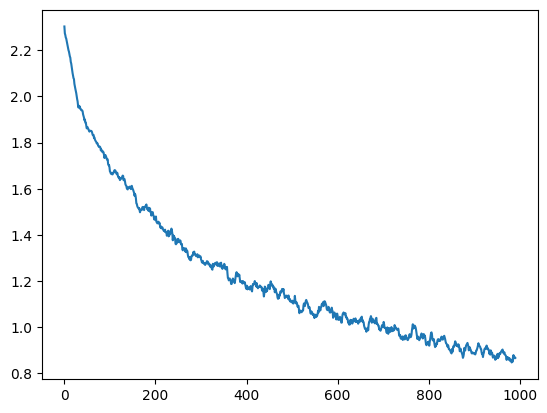

In [ ]:
plt.plot(np.convolve(train_losses, np.ones(10)/10, mode='valid'))
plt.show()

In [ ]:
datasets = []

for k in range(2):
  bucket_name = "gresearch"
  file_path = f"cifar5m/part{k}.npz"

  # Download and load part k
  data = download_and_load_npz(bucket_name, file_path)
  dataset = CIFAR5m(data['X'], data['Y'])
  datasets += [dataset]

/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [ ]:
import random

def train_model(width, lr, T, batch_size = 32, gamma0 = 1.0, use_schedule = False, noise_label = 0.0, zeta = 0.25):

  model = CNN(width = width, gamma0 = gamma0)

  optimizer = optim.SGD(model.parameters(), model.gamma0**2 * model.final_width * lr, momentum = 0.0)

  if use_schedule:
    #scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T)
    scheduler = optim.lr_scheduler.PolynomialLR(optimizer, total_iters = T, power = zeta)
  else:
    scheduler = None

  criterion = nn.CrossEntropyLoss()
  device = 'cuda' if torch.cuda.is_available() else 'cpu'

  model.to(device)

  eval_every = 10
  train_losses = []
  train_loss = 0
  correct = 0
  total = 0
  counter = 0
  eval_every = 10
  random.seed(0)
  torch.manual_seed(0)
  np.random.seed(0)

  train_losses = []

  total_batches = 0

  finished_run = False
  for k in range(5):

    data_k = datasets[k]
    dataloader = DataLoader(data_k, batch_size=batch_size, shuffle=False, num_workers = 4)


    for batch_idx, (inputs, targets) in enumerate(dataloader):

        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)

        # corrupt targets

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        if use_schedule:
          scheduler.step()


        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)

        sys.stdout.write(f'\r loss = {loss.item()}')
        if batch_idx % eval_every == 0 and batch_idx > 0:
            train_losses += [train_loss/eval_every]
            train_loss = 0
            counter = 0
        counter += 1

        if total_batches > T:

          finished_run = True
          print(" ")
          print("done")
          print(" ")
          break

        total_batches += 1


    if finished_run:
      break

  return train_losses

In [ ]:
Tvals = [1000]
width = 32
lr = 0.02
gamma0 = 1.0
batch_size = 32
all_loss = []
for i, T in enumerate(Tvals):
  print(f"T = {T}")
  print(" ")
  all_loss += [train_model(width = width, lr = lr, batch_size = batch_size, gamma0=gamma0, T = T)]

T = 1000
 
 loss = 1.0952446460723877 
done
 


# Width Sweep

In [ ]:
gamma0 = 1.0
#eta_vals = np.logspace(-3,-0.5,8)
eta_vals = np.logspace(-2.5,-0.6,8)
widths = [8,16,32,64]
batch_size = 32
T = 25000

all_loss_width = []
for i, width in enumerate(widths):
  all_loss_i =[]
  for j, lr in enumerate(eta_vals):
    print(f"eta = {lr}")
    save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}.npy' # Example: saving to a folder named 'Colab_Output'
    loss_ij = train_model(width = width, lr = lr, batch_size = batch_size, gamma0=gamma0, T = T)
    all_loss_i += [loss_ij]
    np.save(save_path, loss_ij)

  all_loss_width += [all_loss_i]

eta = 0.0031622776601683794
 loss = 1.1846860647201538 
done
 
eta = 0.005907837911587943
 loss = 0.7078158855438232 
done
 
eta = 0.011037155032027568
 loss = 0.7434261441230774

KeyboardInterrupt: 

In [ ]:
#eta_vals = np.logspace(-3,-0.5,8)
eta_vals = np.logspace(-2.5,-0.6,8)
widths = [8,16,32,64]
batch_size = 32
T = 25000

all_loss_width_loaded = []

for i, width in enumerate(widths):
  all_loss_i =[]
  for j, lr in enumerate(eta_vals):
    print(f"eta = {lr}")
    save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}.npy' # Example: saving to a folder named 'Colab_Output'
    all_loss_i += [np.load(save_path)]
  all_loss_width_loaded += [all_loss_i]

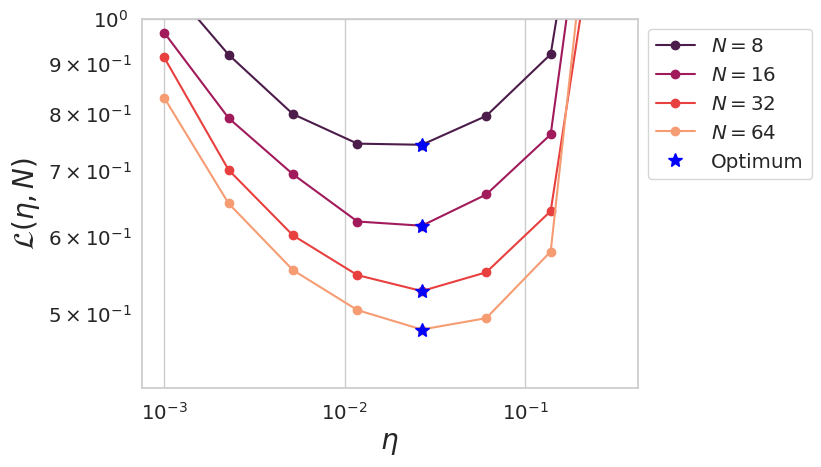

In [ ]:
import seaborn as sns
sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(all_loss_width))

for i, width in enumerate(widths):

  losses_final = np.array([ np.array(loss[-100:-1]).mean() for loss in all_loss_width[i] ])
  plt.loglog( eta_vals, losses_final, '-o' , label = f'$N = {width}$')
  indmin = np.argmin(   losses_final )
  plt.plot( [eta_vals[indmin]] , [ losses_final[indmin] ] , '*', color = 'blue' , markersize = 10)
plt.ylim([0.42,1.0])
plt.plot([],[],  '*', markersize=10,color = 'blue' , label = 'Optimum')
plt.xlabel(r"$\eta$", fontsize = 20)
plt.ylabel(r"$\mathcal{L}(\eta, N)$",  fontsize = 20)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
#plt.savefig(f'cifar5m_lr_transfer_across_width_no_schedule_T_{T}.pdf',bbox_inches='tight')
#plt.savefig(f'/content/drive/MyDrive/LR_Schedule/cifar5m_lr_transfer_across_width_no_schedule_T_{T}.pdf',bbox_inches='tight')
plt.show()


Mounted at /content/drive


In [ ]:
gamma0 = 1.0
eta_vals = np.logspace(-3,-0.5,8)
Tvals = [ 100000 ]
width = 16
batch_size = 32
all_loss_Tvals = []
for i, T in enumerate(Tvals):
  all_loss_i =[]
  for j, lr in enumerate(eta_vals):
    print(f"eta = {lr}")

    loss_ij = train_model(width = width, lr = lr, batch_size = batch_size, gamma0=gamma0, T = T)
    all_loss_i += [ loss_ij ]

    save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}.npy' # Example: saving to a folder named 'Colab_Output'
    np.save(save_path, loss_ij)

  all_loss_Tvals += [all_loss_i]

eta = 0.001
 loss = 0.6741169095039368 
done
 
eta = 0.0022758459260747888
 loss = 0.4402269721031189 
done
 
eta = 0.005179474679231213
 loss = 0.4529435336589813 
done
 
eta = 0.011787686347935871
 loss = 0.5804184079170227 
done
 
eta = 0.02682695795279726
 loss = 0.6589624881744385 
done
 
eta = 0.0610540229658533
 loss = 0.4766397476196289 
done
 
eta = 0.13894954943731375
 loss = 2.3025851249694824 
done
 
eta = 0.31622776601683794
 loss = 2.3025851249694824 
done
 


In [ ]:
eta_vals = np.logspace(-3,-0.5,8)
width = 16
batch_size = 32
Tvals = [1000,2500,5000,10000, 25000, 50000, 100000]

all_loss_Tvals_loaded = []

for i, T in enumerate(Tvals):
  all_loss_i =[]
  for j, lr in enumerate(eta_vals):
    print(f"eta = {lr}")
    save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}.npy' # Example: saving to a folder named 'Colab_Output'
    all_loss_i += [np.load(save_path)]
  all_loss_Tvals_loaded += [all_loss_i]

eta = 0.001
eta = 0.0022758459260747888
eta = 0.005179474679231213
eta = 0.011787686347935871
eta = 0.02682695795279726
eta = 0.0610540229658533
eta = 0.13894954943731375
eta = 0.31622776601683794
eta = 0.001
eta = 0.0022758459260747888
eta = 0.005179474679231213
eta = 0.011787686347935871
eta = 0.02682695795279726
eta = 0.0610540229658533
eta = 0.13894954943731375
eta = 0.31622776601683794
eta = 0.001
eta = 0.0022758459260747888
eta = 0.005179474679231213
eta = 0.011787686347935871
eta = 0.02682695795279726
eta = 0.0610540229658533
eta = 0.13894954943731375
eta = 0.31622776601683794
eta = 0.001
eta = 0.0022758459260747888
eta = 0.005179474679231213
eta = 0.011787686347935871
eta = 0.02682695795279726
eta = 0.0610540229658533
eta = 0.13894954943731375
eta = 0.31622776601683794
eta = 0.001
eta = 0.0022758459260747888
eta = 0.005179474679231213
eta = 0.011787686347935871
eta = 0.02682695795279726
eta = 0.0610540229658533
eta = 0.13894954943731375
eta = 0.31622776601683794
eta = 0.001
eta

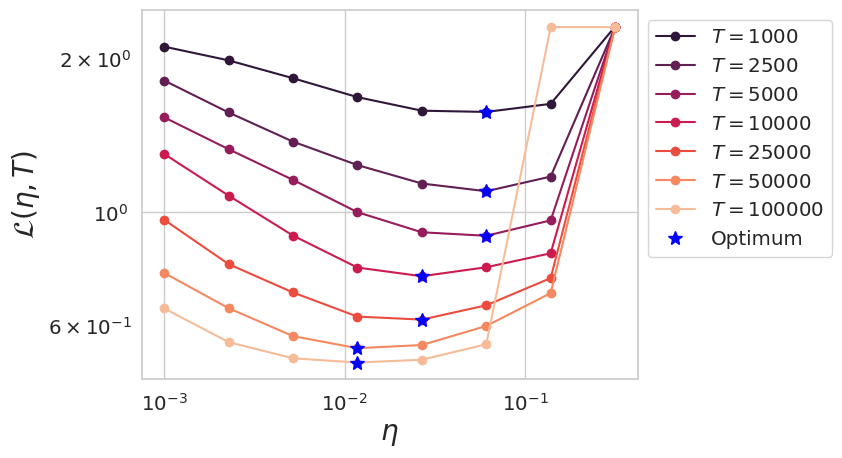

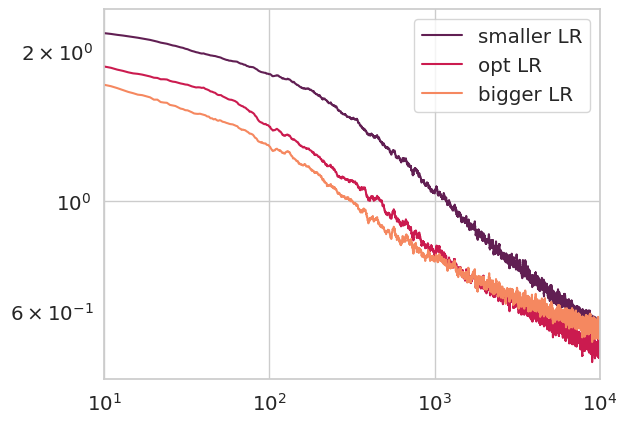

In [ ]:
import seaborn as sns

sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(all_loss_Tvals_loaded))

for i, T in enumerate(Tvals):

  losses_final = np.array([ np.array(loss[-100:-1]).mean() for loss in all_loss_Tvals_loaded[i] ])
  plt.loglog( eta_vals, losses_final, '-o' , label = f'$T = {T}$')
  indmin = np.argmin(   losses_final )
  plt.plot( [eta_vals[indmin]] , [ losses_final[indmin] ] , '*', color = 'blue' , markersize = 10)
#plt.ylim([0.25,2.2])
plt.plot([],[],  '*', markersize=10,color = 'blue' , label = 'Optimum')
plt.xlabel(r"$\eta$", fontsize = 20)
plt.ylabel(r"$\mathcal{L}(\eta, T)$",  fontsize = 20)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.savefig(f'cifar5m_lr_transfer_across_T_no_schedule_width_{width}.pdf',bbox_inches='tight')
plt.savefig(f'/content/drive/MyDrive/LR_Schedule/cifar5m_lr_transfer_across_T_no_schedule_width_{width}.pdf',bbox_inches='tight')
plt.show()


long_runs = all_loss_Tvals_loaded[-1]

conv_long0 = np.convolve(long_runs[1], np.ones(25)/25, mode='valid')
conv_long = np.convolve(long_runs[3], np.ones(25)/25, mode='valid')

conv_long2 = np.convolve(long_runs[5], np.ones(25)/25, mode='valid')

sns.set_palette("rocket", n_colors=3)
plt.loglog(conv_long0, label = 'smaller LR')
plt.loglog(conv_long, label = 'opt LR')
plt.loglog(conv_long2, label = 'bigger LR')
plt.legend()
plt.xlim([10,10000])
plt.show()


## Polynomial Decay LR

In [ ]:
gamma0 = 1.0
eta_vals = np.logspace(-3,-0.5,8)
Tvals = [ 100000 ]
width = 16
batch_size = 32
zeta = 1.0
all_loss_Tvals = []
for i, T in enumerate(Tvals):
  all_loss_i =[]
  for j, lr in enumerate(eta_vals):
    print(f"eta = {lr}")

    loss_ij = train_model(width = width, lr = lr, batch_size = batch_size, gamma0=gamma0, T = T, use_schedule = True, zeta = zeta)
    all_loss_i += [ loss_ij ]

    save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}_poly_sch_zeta_{zeta:.3f}.npy' # Example: saving to a folder named 'Colab_Output'
    np.save(save_path, loss_ij)

  all_loss_Tvals += [all_loss_i]

eta = 0.001
 loss = 0.7222421169281006 
done
 
eta = 0.0022758459260747888
 loss = 0.7517557144165039

KeyboardInterrupt: 

In [ ]:
gamma0 = 1.0
eta_vals = np.logspace(-3,-0.5,8)
Tvals = [ 1000, 2500, 5000, 10000, 25000, 50000,100000 ]
width = 16
batch_size = 32
zeta = 1.0

all_loss_Tvals_loaded = []

for i, T in enumerate(Tvals):
  all_loss_i =[]
  for j, lr in enumerate(eta_vals):
    print(f"eta = {lr}")
    save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}_poly_sch_zeta_{zeta:.3f}.npy' # Example: saving to a folder named 'Colab_Output'
    all_loss_i += [np.load(save_path)]
  all_loss_Tvals_loaded += [all_loss_i]

eta = 0.001
eta = 0.0022758459260747888
eta = 0.005179474679231213
eta = 0.011787686347935871
eta = 0.02682695795279726
eta = 0.0610540229658533
eta = 0.13894954943731375
eta = 0.31622776601683794
eta = 0.001
eta = 0.0022758459260747888
eta = 0.005179474679231213
eta = 0.011787686347935871
eta = 0.02682695795279726
eta = 0.0610540229658533
eta = 0.13894954943731375
eta = 0.31622776601683794
eta = 0.001
eta = 0.0022758459260747888
eta = 0.005179474679231213
eta = 0.011787686347935871
eta = 0.02682695795279726
eta = 0.0610540229658533
eta = 0.13894954943731375
eta = 0.31622776601683794
eta = 0.001
eta = 0.0022758459260747888
eta = 0.005179474679231213
eta = 0.011787686347935871
eta = 0.02682695795279726
eta = 0.0610540229658533
eta = 0.13894954943731375
eta = 0.31622776601683794
eta = 0.001
eta = 0.0022758459260747888
eta = 0.005179474679231213
eta = 0.011787686347935871
eta = 0.02682695795279726
eta = 0.0610540229658533
eta = 0.13894954943731375
eta = 0.31622776601683794
eta = 0.001
eta

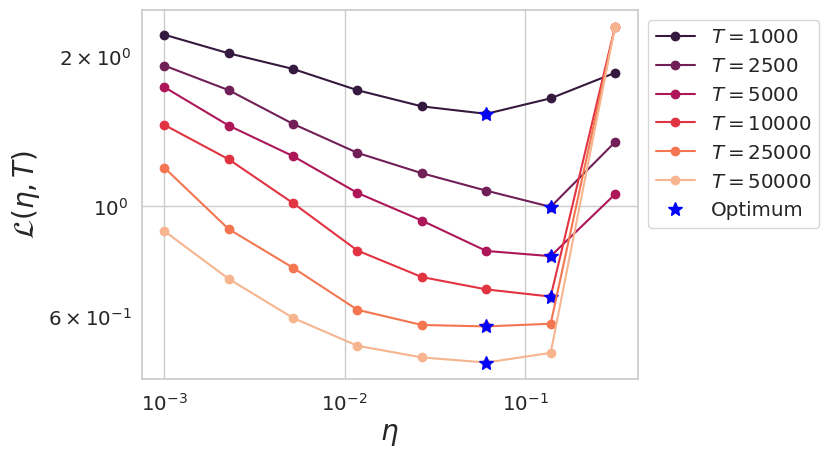

In [ ]:

sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(all_loss_Tvals_loaded))
all_loss_final  = []
for i, T in enumerate(Tvals):

  losses_final = np.array([ np.array(loss[-100:-1]).mean() for loss in all_loss_Tvals_loaded[i] ])
  plt.loglog( eta_vals, losses_final, '-o' , label = f'$T = {T}$')
  indmin = np.argmin(   losses_final )
  plt.plot( [eta_vals[indmin]] , [ losses_final[indmin] ] , '*', color = 'blue' , markersize = 10)

  all_loss_final += [ losses_final ]
#plt.ylim([0.25,2.2])
plt.plot([],[],  '*', markersize=10,color = 'blue' , label = 'Optimum')
plt.xlabel(r"$\eta$", fontsize = 20)
plt.ylabel(r"$\mathcal{L}(\eta, T)$",  fontsize = 20)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.savefig(f'cifar5m_lr_transfer_across_T_poly_schedule_width_{width}_zeta_{zeta:.3f}.pdf',bbox_inches='tight')
plt.savefig(f'/content/drive/MyDrive/LR_Schedule/cifar5m_lr_transfer_across_T_poly_schedule_width_{width}_zeta_{zeta:.3f}.pdf',bbox_inches='tight')
plt.show()

In [ ]:
all_loss_cutoff = [losses[:-1] for losses in all_loss_final]
eta_cutoff = eta_vals[:-1]

eta_stacked = [eta_cutoff for i, T in enumerate(Tvals)]
T_flatten = [ [T for j, eta in enumerate(eta_cutoff)] for i, T in enumerate(Tvals) ]

loss_flatten = np.array(all_loss_cutoff).flatten()
eta_flatten = np.array(eta_stacked).flatten()
T_flatten = np.array(T_flatten).flatten()
print(loss_flatten.shape)
print(eta_flatten.shape)
print(T_flatten.shape)



(42,)
(42,)
(42,)


[ 2.23179495e+00  2.21866316e-01  6.91428226e+01  3.10415060e-01
 -5.43464261e-01  5.23066717e-13]


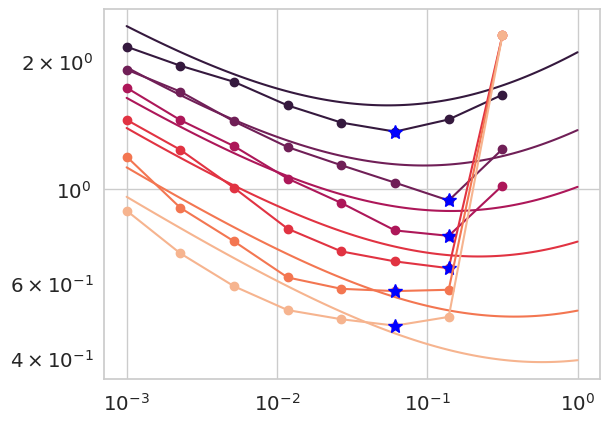

In [ ]:
import scipy as sp

def powerlaw_fn(x, a, b, c, d, e, f):

  etas = x[0]
  Ts = x[1]

  return a * (Ts * etas)**(-b) + c * etas**(d) * Ts**(e)  + f

bounds = [ (0,0,0,-1,-10,0) , (np.inf, np.inf, np.inf, np.inf, np.inf, np.inf) ]
result,_ = sp.optimize.curve_fit(powerlaw_fn, [ eta_flatten, T_flatten ], loss_flatten, p0=[ 5.0 , 0.25 , 5.0, 1.0, 0.1, 0.7 ], bounds=bounds)
print(result)

eta_smooth = np.logspace(-3, 0.0, 100)
for i, T in enumerate(Tvals):
  loss_th = powerlaw_fn([eta_smooth, T*np.ones(len(eta_smooth))], *result)
  plt.loglog(eta_smooth, loss_th)

for i, T in enumerate(Tvals):

  losses_final = np.array([ np.array(loss[-50:-1]).mean() for loss in all_loss_Tvals_loaded[i] ])
  plt.loglog( eta_vals, losses_final, '-o' , label = f'$T = {T}$')
  indmin = np.argmin(   losses_final )
  plt.plot( [eta_vals[indmin]] , [ losses_final[indmin] ] , '*', color = 'blue' , markersize = 10)

plt.show()

In [ ]:
gamma0 = 1.0
#eta_vals = np.logspace(-1.75,-0.5,8)
eta_vals = np.logspace(-2.5,-0.6,8)

Tvals = [ 50000 ]
width = 32
batch_size = 32
zeta = 1.0
all_loss_Tvals = []
for i, T in enumerate(Tvals):
  all_loss_i =[]
  for j, lr in enumerate(eta_vals):
    print(f"eta = {lr}")

    loss_ij = train_model(width = width, lr = lr, batch_size = batch_size, gamma0=gamma0, T = T, use_schedule = True, zeta = zeta)
    all_loss_i += [ loss_ij ]

    save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}_poly_sch_zeta_{zeta:.3f}.npy' # Example: saving to a folder named 'Colab_Output'
    np.save(save_path, loss_ij)

  all_loss_Tvals += [all_loss_i]

eta = 0.0031622776601683794
 loss = 0.7050219178199768 
done
 
eta = 0.005907837911587943
 loss = 0.4187001883983612 
done
 
eta = 0.011037155032027568
 loss = 0.3505189120769501 
done
 
eta = 0.020619860095022202
 loss = 0.36876317858695984 
done
 
eta = 0.03852248420036751
 loss = 0.28786587715148926 
done
 
eta = 0.07196856730011518
 loss = 0.29761195182800293 
done
 
eta = 0.1344532884299761
 loss = 0.24676717817783356 
done
 
eta = 0.251188643150958
 loss = 0.3741726577281952 
done
 


In [ ]:
gamma0 = 1.0
eta_vals = np.logspace(-2.5,-0.6,8)
Tvals = [ 1000, 2500, 5000, 10000, 25000,50000 ]
width = 32
batch_size = 32
zeta = 1.0

all_loss_Tvals_loaded = []

for i, T in enumerate(Tvals):
  all_loss_i =[]
  for j, lr in enumerate(eta_vals):
    #print(f"eta = {lr}")
    save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}_poly_sch_zeta_{zeta:.3f}.npy' # Example: saving to a folder named 'Colab_Output'
    all_loss_i += [np.load(save_path)]
  all_loss_Tvals_loaded += [all_loss_i]

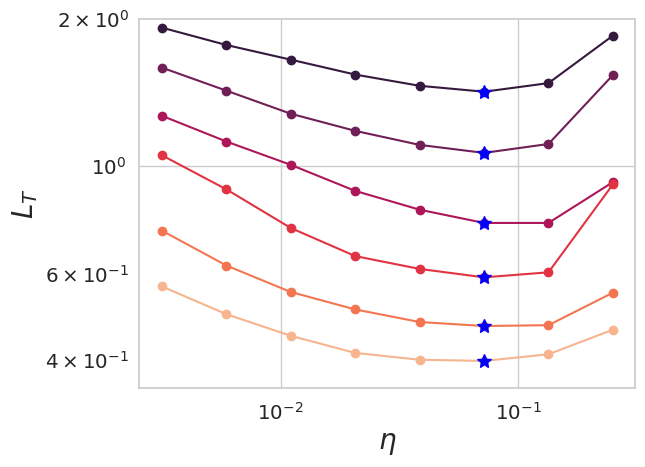

In [ ]:

sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(all_loss_Tvals_loaded))
all_loss_final  = []
for i, T in enumerate(Tvals):

  losses_final = np.array([ np.array(loss[-200:-1]).mean() for loss in all_loss_Tvals_loaded[i] ])
  plt.loglog( eta_vals, losses_final, '-o' , label = f'$T = {T}$')
  indmin = np.argmin(   losses_final )
  plt.plot( [eta_vals[indmin]] , [ losses_final[indmin] ] , '*', color = 'blue' , markersize = 10)

  all_loss_final += [ losses_final ]
plt.ylim([0.35,2.0])
plt.plot([],[],  '*', markersize=10,color = 'blue' , label = 'Optimum')
plt.xlabel(r"$\eta$", fontsize = 20)
plt.ylabel(r"$L_T$",  fontsize = 20)
#plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.savefig(f'cifar5m_lr_transfer_across_T_poly_schedule_width_{width}_zeta_{zeta:.3f}.pdf',bbox_inches='tight')
plt.savefig(f'/content/drive/MyDrive/LR_Schedule/cifar5m_lr_transfer_across_T_poly_schedule_width_{width}_zeta_{zeta:.3f}.pdf',bbox_inches='tight')
plt.show()

In [ ]:
gamma0 = 1.0
#eta_vals = np.logspace(-1.75,-0.5,8)
eta_vals = np.logspace(-2.5,-0.6,8)

Tvals = [ 50000 ]
width = 32
batch_size = 32
zeta = 1.0
all_loss_Tvals = []
for i, T in enumerate(Tvals):
  all_loss_i =[]
  for j, lr in enumerate(eta_vals):
    print(f"eta = {lr}")

    loss_ij = train_model(width = width, lr = lr, batch_size = batch_size, gamma0=gamma0, T = T, use_schedule = False)
    all_loss_i += [ loss_ij ]

    save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}_no_schedule.npy' # Example: saving to a folder named 'Colab_Output'
    np.save(save_path, loss_ij)

  all_loss_Tvals += [all_loss_i]

eta = 0.07196856730011518
 loss = 0.5533726215362549 
done
 
eta = 0.1344532884299761
 loss = 0.5202153325080872 
done
 
eta = 0.251188643150958
 loss = 0.9936532378196716 
done
 


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
gamma0 = 1.0
#eta_vals = np.logspace(-1.75,-0.5,8)
eta_vals = np.logspace(-2.5,-0.6,8)

Tvals = [ 1000, 2500, 5000, 10000, 25000, 50000 ]
width = 32
batch_size = 32
zeta = 1.0

all_loss_Tvals_loaded = []

for i, T in enumerate(Tvals):
  all_loss_i =[]
  for j, lr in enumerate(eta_vals):
    #print(f"eta = {lr}")
    save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}_no_schedule.npy' # Example: saving to a folder named 'Colab_Output'
    all_loss_i += [np.load(save_path)]
  all_loss_Tvals_loaded += [all_loss_i]

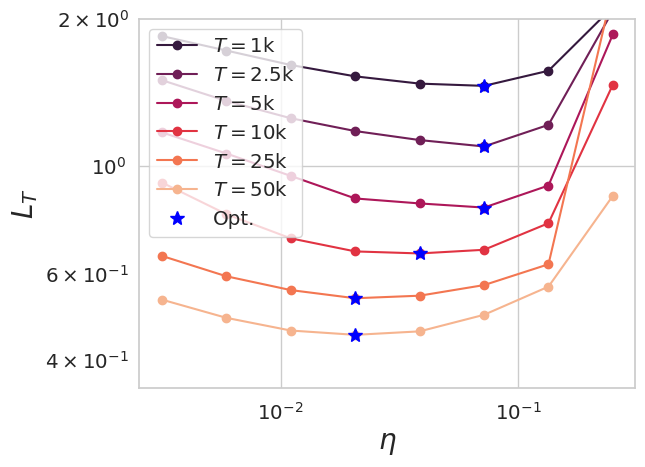

In [ ]:
sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(all_loss_Tvals_loaded))
all_loss_final  = []
labels = ['1k' , '2.5k', '5k','10k','25k','50k']
for i, T in enumerate(Tvals):

  losses_final = np.array([ np.array(loss[-200:-1]).mean() for loss in all_loss_Tvals_loaded[i] ])
  losses_final[np.isnan(losses_final)] = 2.3

  plt.loglog( eta_vals, losses_final, '-o' , label = f'$T = $' + labels[i])
  indmin = np.argmin(   losses_final )
  plt.plot( [eta_vals[indmin]] , [ losses_final[indmin] ] , '*', color = 'blue' , markersize = 10)

  all_loss_final += [ losses_final ]
plt.ylim([0.35,2.0])

plt.plot([],[],  '*', markersize=10,color = 'blue' , label = 'Opt.')
plt.xlabel(r"$\eta$", fontsize = 20)
plt.ylabel(r"$L_T$",  fontsize = 20)
plt.legend(loc='upper left')
plt.savefig(f'cifar5m_lr_transfer_across_T_no_schedule_width_{width}.pdf',bbox_inches='tight')
plt.savefig(f'/content/drive/MyDrive/LR_Schedule/cifar5m_lr_transfer_across_T_no_schedule_width_{width}.pdf',bbox_inches='tight')
plt.show()

# plot loss curves

In [ ]:
width = 32
batch_size = 32
T=50000
lr = eta_vals[-3]
save_path = f'/content/drive/MyDrive/LR_Schedule/cifar5m_supervised_losses_mup_width_{width}_batch_{batch_size}_T_{T}_lr_{lr:.3f}_no_schedule.npy' # Example: saving to a folder named 'Colab_Output'
loss_no_schedule = np.load(save_path)

loss_schedule = [ loss[-3] for loss in all_loss_Tvals_loaded ]

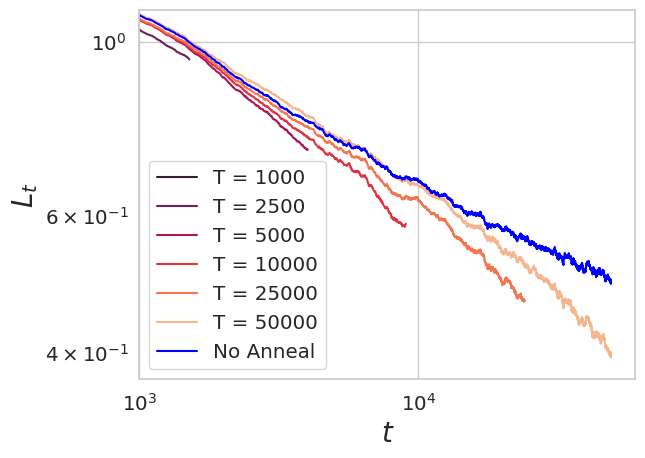

In [ ]:
sns.set_palette("rocket", n_colors=len(all_loss_Tvals_loaded))

for i, loss in enumerate(loss_schedule):

  conv_schedule = np.convolve(loss, np.ones(100)/100, 'valid')
  xgrid = np.linspace(1, 10*len(conv_schedule), len(conv_schedule))

  plt.loglog(xgrid, conv_schedule, label = f'T = {Tvals[i]}')

conv_no_schedule = np.convolve(loss_no_schedule, np.ones(100)/100,'valid')

xgrid = np.linspace(1, 10*len(conv_no_schedule), len(conv_no_schedule))
plt.loglog(xgrid, conv_no_schedule, color ='blue', label = 'No Anneal')
plt.legend()
plt.ylim([0.37, 1.1])
plt.xlim([1000, 60000])

plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$L_t$', fontsize = 20)
plt.savefig('cifar5m_loss_dynamics_schedule_vs_none.pdf', bbox_inches = 'tight')
plt.show()

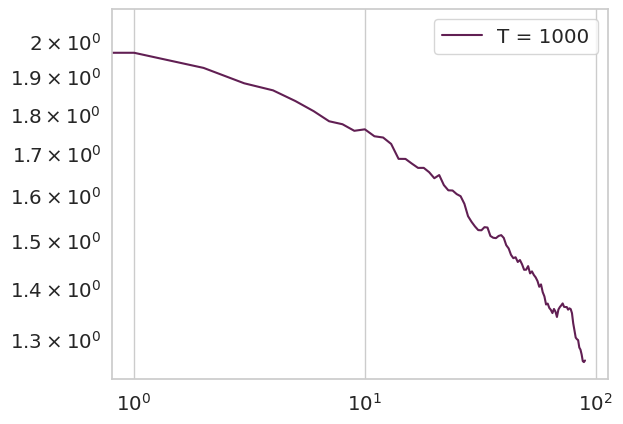

'\nfinal_losses = [ np.array(loss[-100:-1]).mean( ) for loss in all_loss ]\nplt.loglog(Tvals,final_losses)\nplt.show()\n'

In [ ]:
"for i, loss in enumerate(all_loss):
  conv_loss = np.convolve(loss, np.ones(10)/10, mode='valid')
  plt.loglog(conv_loss, label = f"T = {Tvals[i]}")
plt.legend()
plt.show()


"""
final_losses = [ np.array(loss[-100:-1]).mean( ) for loss in all_loss ]
plt.loglog(Tvals,final_losses)
plt.show()
"""